# Cap. 03 — Introducción a los Algoritmos Cuánticos
## Listing 3-12: Algoritmo de Grover (Cirq)

**Referencia:** Pattanayak, *Quantum Machine Learning with Python*, Capítulo 3, Listing 3-12.

---

### Posición en el ecosistema de algoritmos cuánticos

```
Deutsch-Jozsa → Bernstein-Vazirani → Simon → Shor
                                           
                   Grover  ←───────────────── búsqueda no estructurada
```

Grover es el algoritmo cuántico de propósito más general: no requiere que la función tenga una estructura algebraica especial como en Deutsch-Jozsa, BV, Simon o Shor. Solo necesita un oráculo que reconozca la respuesta correcta — y con eso consigue una **aceleración cuadrática** sobre cualquier búsqueda clásica.

---

### Problema que resuelve

Dada una base de datos de $N = 2^n$ elementos indexados por $n$ qubits, existe un **elemento ganador** $k$ con la propiedad:

$$f(x) = \begin{cases} 1 & \text{si } x = k \\ 0 & \text{en otro caso} \end{cases}$$

El objetivo es encontrar $k$ consultando $f$ el menor número de veces posible.

| | Clásico | Cuántico (Grover) |
|---|:---:|:---:|
| Número de consultas | $O(N)$ | $O(\sqrt{N})$ |
| Para $N = 10^6$ | $\sim 500\,000$ | $\sim 1\,000$ |
| Para $N = 2^{64}$ | $\sim 9 \times 10^{18}$ | $\sim 4 \times 10^9$ |

La aceleración cuadrática es **óptima**: se ha demostrado que ningún algoritmo cuántico puede encontrar el elemento ganador en menos de $\Omega(\sqrt{N})$ consultas.

---

### Pasos del algoritmo

| Paso | Acción | Estado |
|---|---|---|
| 0 | $n$ qubits de entrada $\vert 0\rangle^{\otimes n}$ + 1 qubit objetivo $\vert 0\rangle$ | $\vert 0\rangle^n \vert 0\rangle$ |
| 1 | H en cada qubit de entrada + X,H en objetivo | $\vert \psi_{\text{eq}}\rangle \vert -\rangle$ |
| 2 | Oráculo $U_f$ (phase kickback) | $U_f\vert x\rangle = (-1)^{f(x)}\vert x\rangle$ — el ganador recibe fase $-1$ |
| 3 | Operador difusor $U_{\psi_{\text{eq}}}$ (reflexión sobre $\vert \psi_{\text{eq}}\rangle$) | Aumenta amplitud del ganador |
| 4 | Repetir pasos 2-3 un total de $m \approx \frac{\pi}{4}\sqrt{N}$ veces | Estado converge hacia $\vert k\rangle$ |
| 5 | Medir los qubits de entrada | Se obtiene el ganador $k$ con alta probabilidad |

---

### Erratas del libro corregidas

| Libro | Corrección | Motivo |
|---|---|---|
| `"{0:b}".format(k)` sin zero-padding | `format(k, f'0{n}b')` | Sin padding `'01'` puede aparecer como `'1'` |
| `cirq.H.on_each(*input_qubits)` en Moment aparte | Mantenemos la separación del libro para claridad | Sin impacto en resultado |

---

## Explicación profunda del algoritmo

### 1. El problema de búsqueda en términos concretos

Imagina que tienes una caja negra — el oráculo — que puede responder una única pregunta: *¿es este elemento el que buscas?* Responde 1 si sí, 0 si no. La caja negra no te da ninguna otra información: no te dice si estás cerca, no te da pistas de orden. Solo sí o no.

Clásicamente, en el peor caso tienes que preguntar por cada elemento uno a uno. Con $N = 4$ elementos, necesitas hasta 3 preguntas antes de estar seguro (si los tres primeros dicen no, el cuarto es el ganador sin preguntar). En promedio, $N/2$ consultas.

Grover hace algo fundamentalmente diferente: en lugar de preguntar de uno en uno, pregunta a **todos los estados simultáneamente** gracias a la superposición, y usa la interferencia para **amplificar la amplitud del estado ganador** en cada iteración hasta que domina completamente.

---

### 2. El oráculo y el truco del phase kickback

El oráculo cuántico implementa:
$$U_f \vert x\rangle \vert y\rangle = \vert x\rangle \vert y \oplus f(x)\rangle$$

Si el qubit objetivo se prepara en $\vert -\rangle = \frac{\vert 0\rangle - \vert 1\rangle}{\sqrt{2}}$, ocurre el **phase kickback**:

$$U_f \vert x\rangle \vert -\rangle = (-1)^{f(x)} \vert x\rangle \vert -\rangle$$

El qubit objetivo vuelve a $\vert -\rangle$ sin cambiar, pero el estado de entrada recibe una fase $-1$ **solo si $x$ es el ganador**. El oráculo marca al ganador con un signo menos en su amplitud — sin revelar cuál es.

A partir de aquí podemos ignorar el qubit objetivo y pensar solo en los qubits de entrada:
$$U_f \vert x\rangle = (-1)^{f(x)} \vert x\rangle$$

**¿Cómo se implementa el oráculo?**

Para buscar el elemento `01` (ganador = estado $\vert 01\rangle$):
1. Convertir el ganador al estado $\vert 11\rangle$ aplicando X en los bits que son 0 en el ganador (aquí X en Q0, porque `01` tiene 0 en la primera posición).
2. Aplicar una puerta Toffoli (CCNOT) con los qubits de entrada como control y el qubit objetivo como blanco — solo dispara cuando los dos controles son 1, es decir, solo cuando el estado de entrada es el ganador convertido a $\vert 11\rangle$.
3. Deshacer las puertas X del paso 1 para restaurar el estado.

---

### 3. La interpretación geométrica — el corazón del algoritmo

Este es el concepto más importante para entender por qué Grover funciona.

**El espacio de dos dimensiones:**

El estado de los $n$ qubits de entrada vive en un espacio de $2^n$ dimensiones, pero Grover solo necesita 2 dimensiones para explicar todo:
- $\vert k\rangle$: el estado ganador
- $\vert c\rangle$: la superposición uniforme de todos los estados **no ganadores**

El estado de superposición inicial $\vert \psi_{\text{eq}}\rangle$ está en el plano de estas dos dimensiones:

$$\vert \psi_{\text{eq}}\rangle = \sin\theta \vert k\rangle + \cos\theta \vert c\rangle$$

donde $\sin\theta = \frac{1}{\sqrt{N}}$. Para $N = 4$: $\sin\theta = \frac{1}{2}$, entonces $\theta = 30°$.

**Las dos reflexiones:**

Cada iteración de Grover aplica dos reflexiones en este plano 2D:

| Operación | Reflexión sobre | Efecto geométrico |
|---|---|---|
| Oráculo $U_f$ | El eje $\vert c\rangle$ | Niega la componente $\vert k\rangle$ |
| Difusor $U_{\psi_{\text{eq}}}$ | El eje $\vert \psi_{\text{eq}}\rangle$ | Refleja sobre la superposición inicial |

Dos reflexiones consecutivas equivalen a una **rotación de $2\theta$** en la dirección del ganador.

**Evolución del ángulo:**

Empezamos en $\theta = 30°$ y rotamos $2\theta = 60°$ en cada iteración:

| Iteración | Ángulo acumulado | $P(\text{medir ganador})$ |
|:---:|:---:|:---:|
| 0 (inicial) | $30°$ | $\sin^2(30°) = 25\%$ |
| **1** | $90°$ | $\sin^2(90°) = \mathbf{100\%}$ |

Con $N = 4$, una sola iteración de Grover basta para converger al ganador con **probabilidad 1**.

---

### 4. El número óptimo de iteraciones

Para $N$ general, la condición de convergencia es:
$$(2m + 1)\theta = \frac{\pi}{2} \implies m = \frac{\pi/2 - \theta}{2\theta}$$

Para $N$ grande, $\sin\theta \approx \theta \approx \frac{1}{\sqrt{N}}$, lo que da:
$$m \approx \frac{\pi}{4}\sqrt{N}$$

| $N$ | $m$ iteraciones | $P(\text{ganador})$ |
|:---:|:---:|:---:|
| 4 | 1 | 100% |
| 16 | 3 | ~96% |
| 64 | 6 | ~96% |
| 1024 | 25 | ~96% |
| $2^n$ | $\frac{\pi}{4}\sqrt{2^n}$ | $\to 100\%$ |

> **Importante:** si se aplica un número de iteraciones mayor o menor al óptimo, la probabilidad de medir el ganador **disminuye**. El estado rota de más o de menos y ya no apunta exactamente a $\vert k\rangle$.

---

### 5. El operador difusor — reflexión sobre $\vert \psi_{\text{eq}}\rangle$

El difusor implementa $U_{\psi_{\text{eq}}} = 2\vert \psi_{\text{eq}}\rangle\langle \psi_{\text{eq}}\vert - I$, que es la reflexión sobre la superposición igual.

Esta transformación se puede reescribir como:
$$U_{\psi_{\text{eq}}} = H^{\otimes n} \cdot (2\vert 0\rangle^n\langle 0\vert^n - I) \cdot H^{\otimes n}$$

El término $2\vert 0\rangle^n\langle 0\vert^n - I$ es un **flip de fase condicional**: deja igual al estado $\vert 00\ldots 0\rangle$ y aplica $-1$ a todos los demás. Se implementa con puertas X, H y CNOT:

| Paso del difusor | Puertas |
|---|---|
| 1. Deshacer la superposición | $H^{\otimes n}$ |
| 2. Marcar el estado $\vert 00\ldots 0\rangle$ | $X^{\otimes n}$ |
| 3. Flip de fase condicional con CNOT | $H \cdot CNOT \cdot H$ en el último qubit |
| 4. Deshacer el marcado | $X^{\otimes n}$ |
| 5. Reaplicar la superposición | $H^{\otimes n}$ |

---
## Implementación

### Oráculo

El oráculo recibe el elemento ganador como cadena de bits (`secret_element`). Para marcarlo con fase $-1$ mediante phase kickback:
1. Aplica X en los qubits donde el ganador tiene un 0 (para convertirlo a $\vert 11\rangle$).
2. Aplica Toffoli con los dos qubits de entrada como control y el qubit objetivo (en $\vert -\rangle$) como blanco.
3. Deshace las X del paso 1.

In [1]:
import cirq


def oracle(input_qubits, target_qubit, circuit, secret_element='01'):
    """
    Oráculo de Grover para búsqueda del elemento secret_element.

    Aplica fase -1 al estado |secret_element⟩ mediante phase kickback:
      1. X en qubits con bit 0 → convierte el ganador a |11⟩
      2. Toffoli(input[0], input[1] → target) → dispara solo para |11⟩
      3. Deshace las X del paso 1
    """
    print(f"Elemento buscado: {secret_element}")

    # Paso 1: convertir el ganador a |11...1⟩
    for i, bit in enumerate(secret_element):
        if int(bit) == 0:
            circuit.append(cirq.X(input_qubits[i]))

    # Paso 2: Toffoli con todos los qubits de entrada como control
    # Solo dispara cuando todos los controles son 1 → solo para el ganador
    circuit.append(cirq.TOFFOLI(*input_qubits, target_qubit))

    # Paso 3: restaurar los qubits de entrada
    for i, bit in enumerate(secret_element):
        if int(bit) == 0:
            circuit.append(cirq.X(input_qubits[i]))

    return circuit

### Algoritmo completo

El algoritmo separa claramente las tres partes:
1. **Preparación**: superposición uniforme + qubit objetivo en $\vert -\rangle$
2. **Oráculo** $U_f$: marca el ganador con fase $-1$
3. **Difusor** $U_{\psi_{\text{eq}}}$: amplifica la amplitud del ganador

In [2]:
def grovers_algorithm(num_qubits=2, copies=1000, secret_element='01'):
    """
    Implementa el algoritmo de Grover para búsqueda en una base de datos
    de N = 2^num_qubits elementos.

    num_qubits:     número de qubits de entrada (tamaño del índice)
    copies:         repeticiones de la simulación
    secret_element: cadena binaria del elemento ganador

    Retorna: (circuit, out_result) donde out_result es un dict {cadena: conteo}
    """
    input_qubits = [cirq.LineQubit(i) for i in range(num_qubits)]
    target_qubit = cirq.LineQubit(num_qubits)
    circuit = cirq.Circuit()

    # --- Preparación ---
    # Superposición uniforme sobre todos los estados de entrada
    circuit.append([cirq.H(input_qubits[i]) for i in range(num_qubits)])
    # Qubit objetivo en |−⟩ = H|1⟩ = (|0⟩ - |1⟩)/√2 para el phase kickback
    circuit.append([cirq.X(target_qubit), cirq.H(target_qubit)])

    # --- Oráculo U_f ---
    # Aplica fase -1 al estado ganador mediante phase kickback con el qubit objetivo
    circuit = oracle(input_qubits, target_qubit, circuit, secret_element)

    # --- Difusor U_ψeq ---
    # Implementa la reflexión 2|ψeq⟩⟨ψeq| - I sobre la superposición uniforme.
    # Equivalente a H⊗n (2|0⟩⟨0| - I) H⊗n.

    # Paso 1: deshacer la superposición
    circuit.append(cirq.H.on_each(*input_qubits))
    # Paso 2: marcar el estado |00⟩ convirtiéndolo a |11⟩
    circuit.append(cirq.X.on_each(*input_qubits))
    # Pasos 3-4-5: flip de fase condicional sobre |11⟩
    #   H · CNOT · H en el último qubit = controlled-Z (CZ) en forma equivalente
    circuit.append(cirq.H.on(input_qubits[1]))
    circuit.append(cirq.CNOT(input_qubits[0], input_qubits[1]))
    circuit.append(cirq.H.on(input_qubits[1]))
    # Paso 6: deshacer el marcado del paso 2
    circuit.append(cirq.X.on_each(*input_qubits))
    # Paso 7: reaplicar la superposición
    circuit.append(cirq.H.on_each(*input_qubits))

    # --- Medición ---
    circuit.append(cirq.measure(*input_qubits, key='Z'))

    sim = cirq.Simulator()
    result = sim.run(circuit, repetitions=copies)
    out = result.histogram(key='Z')

    # Convertir enteros a cadenas binarias con zero-padding
    out_result = {
        format(k, f'0{num_qubits}b'): v
        for k, v in out.items()
    }
    return circuit, out_result

### Ejecución con el elemento del libro: `01`

In [3]:
circuit, out_result = grovers_algorithm(num_qubits=2, copies=1000, secret_element='01')
print("Circuito de Grover:")
print(circuit)

Elemento buscado: 01
Circuito de Grover:
0: ───H───X───@───X───H───X───@───X───H───────M('Z')───
              │               │               │
1: ───H───────@───H───X───H───X───H───X───H───M────────
              │
2: ───X───H───X────────────────────────────────────────


### Visualización del circuito

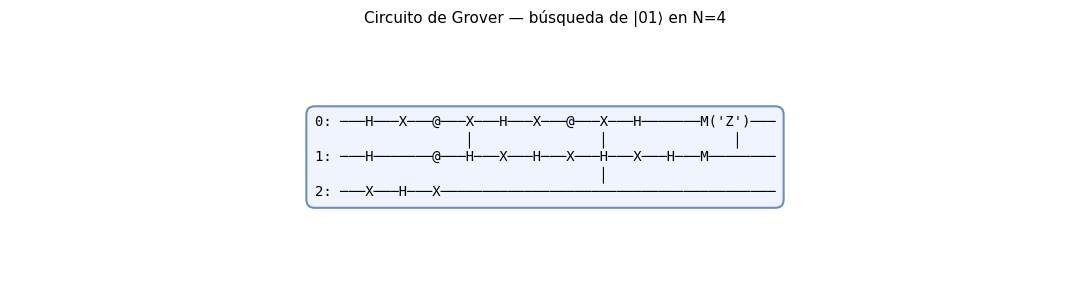

In [4]:
import matplotlib.pyplot as plt

diagrama = circuit.to_text_diagram()

fig, ax = plt.subplots(figsize=(11, 3))
ax.text(
    0.5, 0.5, diagrama,
    fontfamily='monospace', fontsize=10,
    ha='center', va='center',
    bbox=dict(
        boxstyle='round,pad=0.6',
        facecolor='#f0f4ff',
        edgecolor='#6c8ebf',
        linewidth=1.5,
    ),
)
ax.axis('off')
ax.set_title('Circuito de Grover — búsqueda de |01⟩ en N=4', fontsize=11, pad=8)
plt.tight_layout()
plt.show()

### Histograma de resultados

Con $N = 4$ y 1 iteración, el algoritmo converge al ganador con probabilidad 1.
Las 1000 mediciones deben colapsar todas al estado $\vert 01\rangle$.

Resultados: {'01': 1000}


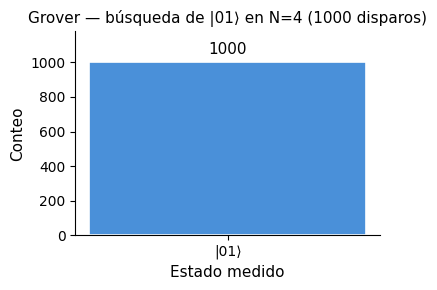

In [5]:
from qml_santanu.common.plot_utils import plot_counts

print(f"Resultados: {out_result}")
plot_counts(out_result, title='Grover — búsqueda de |01⟩ en N=4')

### Verificación con los cuatro posibles ganadores

Para un espacio de $N = 4$ elementos ($\{00, 01, 10, 11\}$), verificamos que el algoritmo converge correctamente para cualquier ganador, no solo para `01`.

In [6]:
ganadores = ['00', '01', '10', '11']

for elemento in ganadores:
    _, result = grovers_algorithm(num_qubits=2, copies=500, secret_element=elemento)
    recuperado = max(result, key=result.get)
    correcto = recuperado == elemento
    print(f"Buscado: |{elemento}⟩  →  Medido: |{recuperado}⟩  {'✓' if correcto else '✗'}")

Elemento buscado: 00
Buscado: |00⟩  →  Medido: |00⟩  ✓
Elemento buscado: 01
Buscado: |01⟩  →  Medido: |01⟩  ✓
Elemento buscado: 10
Buscado: |10⟩  →  Medido: |10⟩  ✓
Elemento buscado: 11
Buscado: |11⟩  →  Medido: |11⟩  ✓


### Análisis de la distribución de probabilidades

Comparamos la distribución de resultados con y sin el algoritmo de Grover.

- **Sin Grover** (solo superposición): cada estado tiene probabilidad $\frac{1}{4} = 25\%$.
- **Con Grover** (1 iteración): el ganador tiene probabilidad $\approx 100\%$, los demás $\approx 0\%$.

Elemento buscado: 01


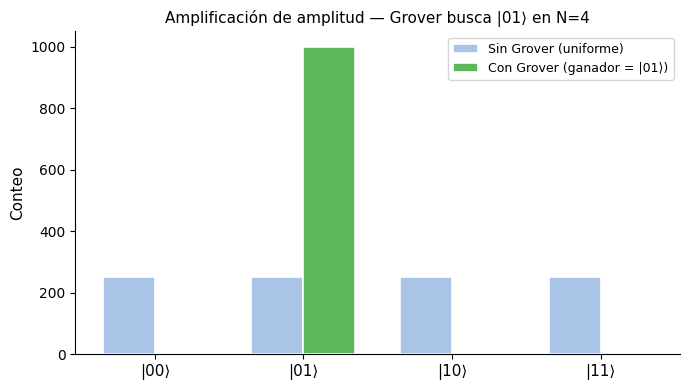

In [7]:
import numpy as np

SHOTS = 1000
SECRET = '01'

# Sin Grover: distribución uniforme (simulada)
estados = ['00', '01', '10', '11']
sin_grover = {e: SHOTS // 4 for e in estados}

# Con Grover
_, con_grover = grovers_algorithm(num_qubits=2, copies=SHOTS, secret_element=SECRET)
# Completar con ceros los estados que no aparecieron
for e in estados:
    con_grover.setdefault(e, 0)

x = np.arange(len(estados))
ancho = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
barras_sin = ax.bar(
    x - ancho / 2, [sin_grover[e] for e in estados],
    ancho, label='Sin Grover (uniforme)',
    color='#aac4e8', edgecolor='white', linewidth=1.2,
)
barras_con = ax.bar(
    x + ancho / 2, [con_grover[e] for e in estados],
    ancho, label=f'Con Grover (ganador = |{SECRET}⟩)',
    color='#5cb85c', edgecolor='white', linewidth=1.2,
)

ax.set_xticks(x)
ax.set_xticklabels([f'|{e}⟩' for e in estados], fontsize=11)
ax.set_ylabel('Conteo', fontsize=11)
ax.set_title(
    f'Amplificación de amplitud — Grover busca |{SECRET}⟩ en N=4',
    fontsize=11,
)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

---

## Conclusión

### ¿Qué hace el algoritmo de Grover?

Grover encuentra un elemento marcado en una base de datos de $N = 2^n$ elementos con $O(\sqrt{N})$ consultas al oráculo, comparado con $O(N)$ de cualquier algoritmo clásico. Es la aceleración cuadrática más general que existe en computación cuántica.

---

### El mecanismo central: amplificación de amplitud

Lo que hace Grover no es buscar — es **manipular probabilidades**. Empieza con una distribución uniforme donde el ganador tiene probabilidad $\frac{1}{N}$, y mediante dos reflexiones geométricas consecutivas (el oráculo y el difusor) rota el estado cuántico acercándolo al ganador en $2\theta$ por iteración.

Para $N = 4$: el ángulo inicial es $30°$ y cada iteración rota $60°$. Con una sola iteración llegamos a $90°$ — el estado ganador puro con probabilidad 1.

Para $N$ grande: se necesitan $\approx \frac{\pi}{4}\sqrt{N}$ iteraciones. Más o menos de ese número exacto **reduce la probabilidad** — hay que conocer $N$ de antemano para calcular el número óptimo.

---

### Lo que el algoritmo SÍ hace

- Busca cualquier elemento en una base de datos desestructurada en $O(\sqrt{N})$ consultas.
- Funciona con **cualquier oráculo** que identifique el ganador, sin necesidad de estructura adicional.
- Aplicable como subrutina de optimización: encontrar el mínimo de una función discreta en $O(\sqrt{N})$ evaluaciones.

---

### Lo que el algoritmo NO hace

- **No es exponencial**: la ventaja es cuadrática ($\sqrt{N}$), no exponencial ($\log N$). Grover no rompe la criptografía simétrica, solo obliga a duplicar el tamaño de las claves.
- **No funciona para funciones sin oráculo claro**: si no sabes definir una función que identifique la solución, no tienes oráculo, y sin oráculo no hay Grover.
- **No puede mejorarse más**: se ha demostrado que $\Omega(\sqrt{N})$ es un límite inferior cuántico — ningún algoritmo cuántico puede hacerlo mejor para búsqueda no estructurada.

---

### Aplicaciones reales

| Área | Aplicación |
|---|---|
| Criptografía | Búsqueda de preimagen de funciones hash (ataque de fuerza bruta cuántico) |
| Optimización | Encontrar el mínimo de una función discreta (quantum minimum finding) |
| Machine Learning | Búsqueda del vecino más cercano en bases de datos cuánticas |
| QML (cap. 5) | El oráculo de Grover aparece como subrutina en algoritmos cuánticos de ML |

> La amplificación de amplitud — el principio subyacente a Grover — es una de las herramientas más utilizadas en algoritmos cuánticos avanzados, incluyendo los que veremos en los capítulos 5 y 6.